<a href="https://colab.research.google.com/github/Huang-stat/Computer-Labs/blob/main/AKHU_CS_Lab5_Data_Pipelines_Generators_0515.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS Lab 5: Pipeline versus Generator Methods with Test-Set Model Comparison

**Date:** Friday, 15 May 2026, 16:00, Comp. Lab 1  
**Topic:** Data pipelines with generators, variable selection, and test-set model comparison

This notebook connects two ideas:

1. **Generator method:** read and convert a large CSV file one row at a time.
2. **Package pipeline method:** use `scikit-learn` pipelines to standardize features and fit models.

The modeling case study predicts `quiz_score` from activity variables. The final comparison uses the **test set**, not only the training set.

## 0. Colab and VS Code setup

### Colab
Upload the CSV files to Colab, or place them in Google Drive:

```text
/content/AKHU_lab5_activity_log_large.csv
/content/data/AKHU_lab5_activity_log_large.csv
/content/drive/MyDrive/AKHU_labs/AKHU_lab5_activity_log_large.csv
```

### Visual Studio Code / Visual Studio
Open the whole project folder. A clean folder structure is:

```text
your_project_folder/
    AKHU_CS_Lab5_...ipynb
    data/
        AKHU_lab5_activity_log_large.csv
        AKHU_lab5_activity_log_small.csv
```

Run `Path.cwd()` before loading data so you know where Python is searching.

In [1]:
from pathlib import Path
import csv
from itertools import islice
import math
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore", category=UserWarning)

ASSETS_DIR = Path("assets")
OUTPUTS_DIR = Path("outputs")
ASSETS_DIR.mkdir(exist_ok=True)
OUTPUTS_DIR.mkdir(exist_ok=True)

plt.rcParams.update({"figure.figsize": (8, 4.8), "axes.grid": True})
print("Current working directory:", Path.cwd())

Current working directory: /content


## 1. Find the data file

The same notebook should work in Colab and in VS Code. The helper below searches common folders.

In [2]:
CANDIDATE_DIRS = [
    Path("data"),                              # VS Code recommended folder
    Path("."),                                 # current folder
    Path("/content"),                          # Colab upload folder
    Path("/content/data"),                     # Colab data folder
    Path("/content/drive/MyDrive/AKHU_labs"),  # Colab Google Drive folder
    Path("/mnt/data"),                         # grading / local fallback
]


def find_data_file(filename):
    print("Current working directory:", Path.cwd())
    print("Searching for:", filename)
    for folder in CANDIDATE_DIRS:
        candidate = folder / filename
        print("Checking:", candidate)
        if candidate.exists():
            print("Found:", candidate)
            return candidate
    raise FileNotFoundError(
        f"Could not find {filename}. Put it in data/, /content/, or Google Drive AKHU_labs."
    )

path = find_data_file("AKHU_lab5_activity_log_large.csv")

Current working directory: /content
Searching for: AKHU_lab5_activity_log_large.csv
Checking: data/AKHU_lab5_activity_log_large.csv
Checking: AKHU_lab5_activity_log_large.csv
Found: AKHU_lab5_activity_log_large.csv


## 2. Pipeline versus generator: two different ideas

| Term | What it controls | Why it matters |
|---|---|---|
| Python generator | Data flow from the CSV file | Reads one row at a time, useful for large files. |
| Data pipeline | A sequence of cleaning/conversion/filtering steps | Keeps preparation organized. |
| `scikit-learn` Pipeline | Modeling workflow | Applies preprocessing and model fitting in one repeatable object. |

Important: the **generator** helps with memory-efficient input. The **model pipeline** helps with repeatable preprocessing and prediction. They can work together.

## 3. Generator method: stream CSV rows

`csv.DictReader` reads each row as a dictionary. The generator yields one row at a time.

In [3]:
def read_csv_rows(path):
    with Path(path).open(newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            yield row

print("First 3 raw rows:")
for row in islice(read_csv_rows(path), 3):
    print(row)

First 3 raw rows:
{'event_id': 'E00001', 'student_id': 'S105', 'course': 'ST', 'week': '6', 'minutes_studied': '121', 'video_minutes': '42', 'quiz_score': '71.3', 'assignment_score': '67.0', 'late_submission': '0', 'login_count': '7'}
{'event_id': 'E00002', 'student_id': 'S007', 'course': 'MA', 'week': '9', 'minutes_studied': '61', 'video_minutes': '46', 'quiz_score': '74.2', 'assignment_score': '71.4', 'late_submission': '0', 'login_count': '9'}
{'event_id': 'E00003', 'student_id': 'S157', 'course': 'CS', 'week': '7', 'minutes_studied': '65', 'video_minutes': '56', 'quiz_score': '68.8', 'assignment_score': '69.0', 'late_submission': '0', 'login_count': '8'}


## 4. Convert strings to numbers with EAFP style

CSV values are text. Modeling needs numbers. EAFP means: try the conversion first, then handle the error if it fails.

In [4]:
class BadRowError(Exception):
    """Raised when a row cannot be converted."""


def convert_activity_row(row):
    return {
        "event_id": row["event_id"],
        "student_id": row["student_id"],
        "course": row["course"],
        "week": int(row["week"]),
        "minutes_studied": int(row["minutes_studied"]),
        "video_minutes": int(row["video_minutes"]),
        "quiz_score": float(row["quiz_score"]),
        "assignment_score": float(row["assignment_score"]),
        "late_submission": int(row["late_submission"]),
        "login_count": int(row["login_count"]),
    }


def converted_rows(path):
    for line_number, row in enumerate(read_csv_rows(path), start=2):
        try:
            yield convert_activity_row(row)
        except (KeyError, ValueError) as exc:
            raise BadRowError(f"Bad row at CSV line {line_number}: {row}") from exc

first = next(converted_rows(path))
print(first)
print("quiz_score type:", type(first["quiz_score"]))

{'event_id': 'E00001', 'student_id': 'S105', 'course': 'ST', 'week': 6, 'minutes_studied': 121, 'video_minutes': 42, 'quiz_score': 71.3, 'assignment_score': 67.0, 'late_submission': 0, 'login_count': 7}
quiz_score type: <class 'float'>


## 5. Streaming summary before modeling

This function computes a mean, minimum, and maximum without storing the full file.

In [5]:
def streaming_summary(rows, column):
    count = 0
    total = 0.0
    minimum = None
    maximum = None
    for row in rows:
        value = row[column]
        count += 1
        total += value
        minimum = value if minimum is None else min(minimum, value)
        maximum = value if maximum is None else max(maximum, value)
    return {"count": count, "mean": total / count if count else None, "min": minimum, "max": maximum}

streaming_summary(converted_rows(path), "quiz_score")

{'count': 12000, 'mean': 64.14350833333353, 'min': 34.2, 'max': 91.1}

## 6. Build a model-ready table from the generator

Model packages usually need an in-memory table or arrays. The generator is still useful before this point: it can validate, filter, and select rows before the final table is built.

In [6]:
def model_ready_rows(path):
    columns = [
        "minutes_studied",
        "video_minutes",
        "assignment_score",
        "late_submission",
        "login_count",
        "quiz_score",
    ]
    for row in converted_rows(path):
        yield {column: row[column] for column in columns}

# Generator method: convert then build a compact model-ready DataFrame.
df_generator = pd.DataFrame(model_ready_rows(path))

# Direct package method: read the CSV into a DataFrame immediately.
df_direct = pd.read_csv(path)

print("Generator-built table shape:", df_generator.shape)
print("Direct pandas table shape:", df_direct.shape)
df_generator.head()

Generator-built table shape: (12000, 6)
Direct pandas table shape: (12000, 10)


,minutes_studied,video_minutes,assignment_score,late_submission,login_count,quiz_score
0,121,42,67.0,0,7,71.3
1,61,46,71.4,0,9,74.2
2,65,56,69.0,0,8,68.8
3,103,74,60.6,0,3,64.3
4,140,38,71.2,0,5,70.4


## 7. EDA plots

Before modeling, inspect the target and the predictors.

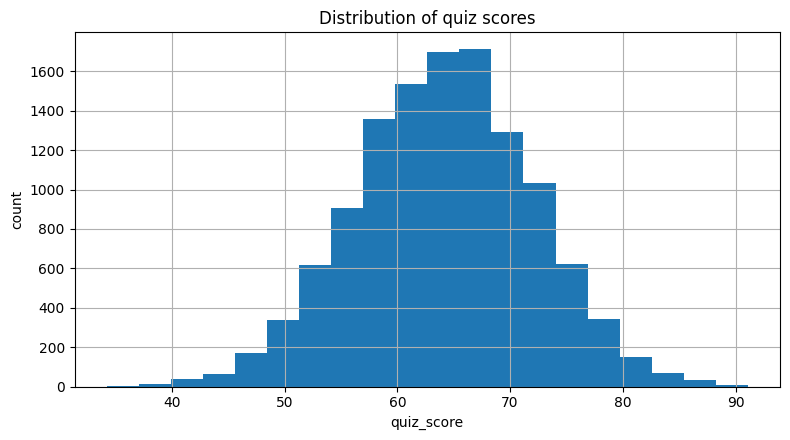

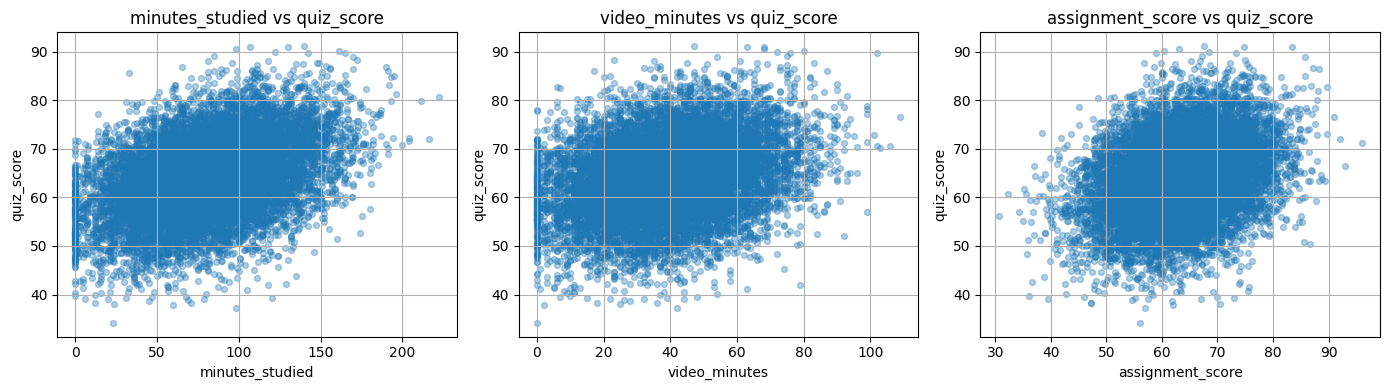

In [7]:
features = ["minutes_studied", "video_minutes", "assignment_score", "late_submission", "login_count"]
target = "quiz_score"

df = df_generator.copy()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df[target], bins=20)
ax.set_title("Distribution of quiz scores")
ax.set_xlabel("quiz_score")
ax.set_ylabel("count")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "lab5_quiz_score_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["minutes_studied", "video_minutes", "assignment_score"]):
    ax.scatter(df[col], df[target], alpha=0.35, s=18)
    ax.set_xlabel(col)
    ax.set_ylabel(target)
    ax.set_title(f"{col} vs {target}")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "lab5_eda_predictors_vs_target.png", dpi=160, bbox_inches="tight")
plt.show()

## 8. Train, validation, and test split

- Train set: fit model parameters.
- Validation set: choose variables and modeling options.
- Test set: final honest comparison.

Do not use the test set for variable selection.

In [8]:
train_full_df, test_df = train_test_split(df, test_size=0.20, random_state=42, shuffle=True)
train_df, valid_df = train_test_split(train_full_df, test_size=0.25, random_state=42, shuffle=True)

print("Train rows:", len(train_df))
print("Validation rows:", len(valid_df))
print("Test rows:", len(test_df))

Train rows: 7200
Validation rows: 2400
Test rows: 2400


## 9. Evaluation metrics with a self-defined baseline-relative R squared

The baseline-relative R squared compares a model to the mean baseline.

\[
R^2_{baseline} = 1 - \frac{\sum_i (y_i - \hat y_i)^2}{\sum_i (y_i - \hat y_{baseline,i})^2}
\]

The mean baseline has `R2_vs_baseline = 0` by definition.

In [9]:
def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))


def self_defined_r2_vs_baseline(y_true, y_pred, baseline_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    baseline_pred = np.asarray(baseline_pred, dtype=float)
    sse_model = np.sum((y_true - y_pred) ** 2)
    sse_baseline = np.sum((y_true - baseline_pred) ** 2)
    if np.isclose(sse_baseline, 0):
        return np.nan
    return float(1 - sse_model / sse_baseline)


def split_metrics(y_true, y_pred, baseline_value):
    baseline_pred = np.full(len(y_true), baseline_value, dtype=float)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "R2_vs_baseline": self_defined_r2_vs_baseline(y_true, y_pred, baseline_pred),
    }

baseline_value = float(train_df[target].mean())
print("Training mean baseline value:", round(baseline_value, 3))

Training mean baseline value: 64.163


## 10. Variable selection using validation performance

Forward selection starts with no predictors and adds the predictor that most improves validation RMSE. The test set is not touched during selection.

In [10]:
def make_linear_pipeline():
    return make_pipeline(StandardScaler(), LinearRegression())


def validation_rmse_for_features(feature_list):
    model = make_linear_pipeline()
    model.fit(train_df[feature_list], train_df[target])
    pred = model.predict(valid_df[feature_list])
    return rmse(valid_df[target], pred)


def forward_select_features(candidate_features, min_improvement=0.02):
    selected = []
    remaining = list(candidate_features)
    best_score = rmse(valid_df[target], np.full(len(valid_df), baseline_value))
    history = []

    while remaining:
        trials = []
        for feature in remaining:
            trial_features = selected + [feature]
            trial_score = validation_rmse_for_features(trial_features)
            trials.append((trial_score, feature, trial_features))

        trials.sort(key=lambda x: x[0])
        score, feature, trial_features = trials[0]
        improvement = best_score - score
        history.append({
            "step": len(history) + 1,
            "candidate_feature": feature,
            "candidate_features": ", ".join(trial_features),
            "valid_RMSE": score,
            "improvement": improvement,
        })

        if improvement > min_improvement:
            selected = trial_features
            remaining.remove(feature)
            best_score = score
        else:
            break

    return selected, pd.DataFrame(history)

selected_features, selection_history = forward_select_features(features, min_improvement=0.02)
print("Selected features:", selected_features)
selection_history

Selected features: ['minutes_studied', 'login_count', 'video_minutes', 'late_submission']


,step,candidate_feature,candidate_features,valid_RMSE,improvement
0,1,minutes_studied,minutes_studied,7.079654,0.714030
1,2,login_count,"minutes_studied, login_count",6.619260,0.460394
2,3,video_minutes,"minutes_studied, login_count, video_minutes",6.305176,0.314083
3,4,late_submission,"minutes_studied, login_count, video_minutes, l...",6.028068,0.277108
4,5,assignment_score,"minutes_studied, login_count, video_minutes, l...",6.027708,0.000360


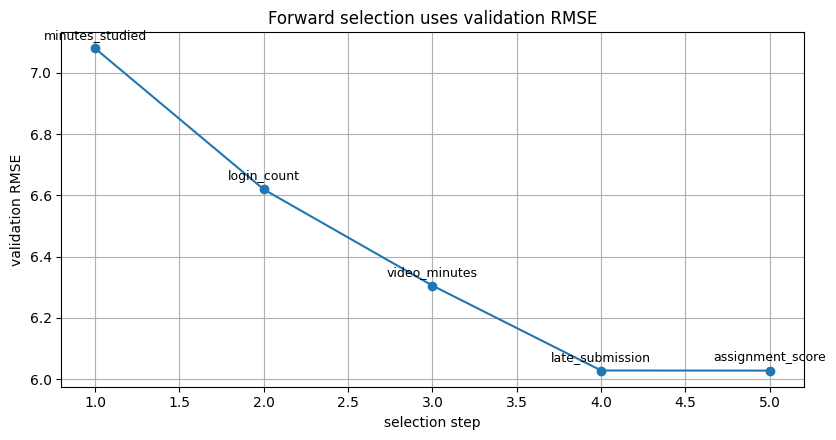

In [11]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(selection_history["step"], selection_history["valid_RMSE"], marker="o")
for _, row in selection_history.iterrows():
    ax.text(row["step"], row["valid_RMSE"] + 0.03, row["candidate_feature"], ha="center", fontsize=9)
ax.set_title("Forward selection uses validation RMSE")
ax.set_xlabel("selection step")
ax.set_ylabel("validation RMSE")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "lab5_variable_selection_path.png", dpi=160, bbox_inches="tight")
plt.show()

## 11. Define model comparison candidates

The comparison includes:

- mean baseline;
- linear regression with different predictors;
- selected multiple linear regression;
- full multiple linear regression;
- neural networks with selected and full predictors.

The `data_method` column separates the **data preparation method** from the **model type**.

In [12]:
def make_mlp_pipeline():
    return make_pipeline(
        StandardScaler(),
        MLPRegressor(
            hidden_layer_sizes=(32, 16),
            activation="relu",
            max_iter=900,
            early_stopping=True,
            random_state=42,
        ),
    )

model_specs = [
    {
        "model": "Linear: minutes only",
        "data_method": "generator table",
        "features": ["minutes_studied"],
        "estimator": LinearRegression(),
    },
    {
        "model": "Linear: minutes + login",
        "data_method": "generator table",
        "features": ["minutes_studied", "login_count"],
        "estimator": LinearRegression(),
    },
    {
        "model": "Selected linear",
        "data_method": "generator table",
        "features": selected_features,
        "estimator": LinearRegression(),
    },
    {
        "model": "Selected linear in sklearn Pipeline",
        "data_method": "sklearn Pipeline",
        "features": selected_features,
        "estimator": make_linear_pipeline(),
    },
    {
        "model": "Full multiple linear in sklearn Pipeline",
        "data_method": "sklearn Pipeline",
        "features": features,
        "estimator": make_linear_pipeline(),
    },
    {
        "model": "Neural network with selected predictors",
        "data_method": "sklearn Pipeline",
        "features": selected_features,
        "estimator": make_mlp_pipeline(),
    },
    {
        "model": "Neural network with all predictors",
        "data_method": "sklearn Pipeline",
        "features": features,
        "estimator": make_mlp_pipeline(),
    },
]

print("Number of model candidates:", len(model_specs) + 1)  # + baseline

Number of model candidates: 8


## 12. Evaluate train, validation, and test performance

The final decision should use the test set. Training performance alone can be misleading, especially for flexible models such as neural networks.

In [13]:
SPLITS = {
    "train": train_df,
    "validation": valid_df,
    "test": test_df,
}

records = []

# Mean baseline
for split_name, split_df in SPLITS.items():
    pred = np.full(len(split_df), baseline_value, dtype=float)
    metrics = split_metrics(split_df[target], pred, baseline_value)
    records.append({
        "model": "Mean baseline",
        "data_method": "constant baseline",
        "features": "none",
        "n_features": 0,
        "split": split_name,
        **metrics,
    })

fitted_models = {}
for spec in model_specs:
    model = spec["estimator"]
    feature_list = spec["features"]
    model.fit(train_df[feature_list], train_df[target])
    fitted_models[spec["model"]] = model

    for split_name, split_df in SPLITS.items():
        pred = model.predict(split_df[feature_list])
        metrics = split_metrics(split_df[target], pred, baseline_value)
        records.append({
            "model": spec["model"],
            "data_method": spec["data_method"],
            "features": ", ".join(feature_list),
            "n_features": len(feature_list),
            "split": split_name,
            **metrics,
        })

metrics_df = pd.DataFrame(records)
test_metrics = metrics_df[metrics_df["split"] == "test"].sort_values("RMSE").reset_index(drop=True)

test_metrics[["model", "data_method", "n_features", "MAE", "RMSE", "R2_vs_baseline"]]

,model,data_method,n_features,MAE,RMSE,R2_vs_baseline
0,Selected linear in sklearn Pipeline,sklearn Pipeline,4,4.866006,6.107775,0.437532
1,Selected linear,generator table,4,4.866006,6.107775,0.437532
2,Full multiple linear in sklearn Pipeline,sklearn Pipeline,5,4.867299,6.111016,0.436935
3,Neural network with all predictors,sklearn Pipeline,5,4.882799,6.128472,0.433714
4,Neural network with selected predictors,sklearn Pipeline,4,4.918779,6.178404,0.424449
5,Linear: minutes + login,generator table,2,5.512764,6.919053,0.278187
6,Linear: minutes only,generator table,1,5.944818,7.448923,0.163399
7,Mean baseline,constant baseline,0,6.506581,8.143933,0.000000


In [14]:
# Save result tables for later inspection.
metrics_df.to_csv(OUTPUTS_DIR / "lab5_train_validation_test_metrics.csv", index=False)
test_metrics.to_csv(OUTPUTS_DIR / "lab5_test_model_comparison.csv", index=False)
selection_history.to_csv(OUTPUTS_DIR / "lab5_variable_selection_history.csv", index=False)

print("Saved outputs:")
for file in OUTPUTS_DIR.glob("*.csv"):
    print(" ", file)

Saved outputs:
  outputs/lab5_variable_selection_history.csv
  outputs/lab5_test_model_comparison.csv
  outputs/lab5_train_validation_test_metrics.csv


## 13. Plot test-set model comparison

Smaller MAE and RMSE are better. Larger `R2_vs_baseline` is better.

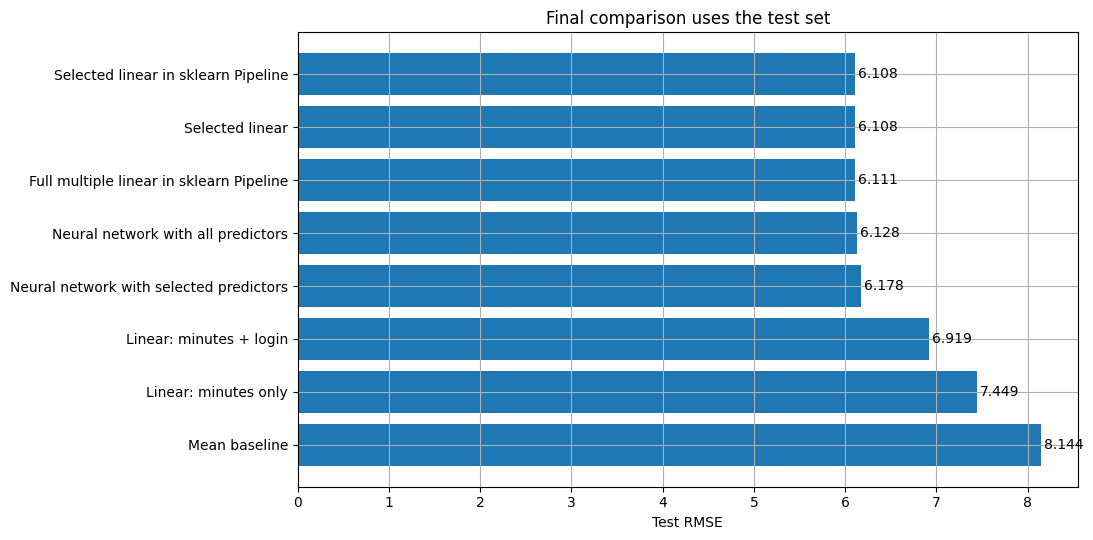

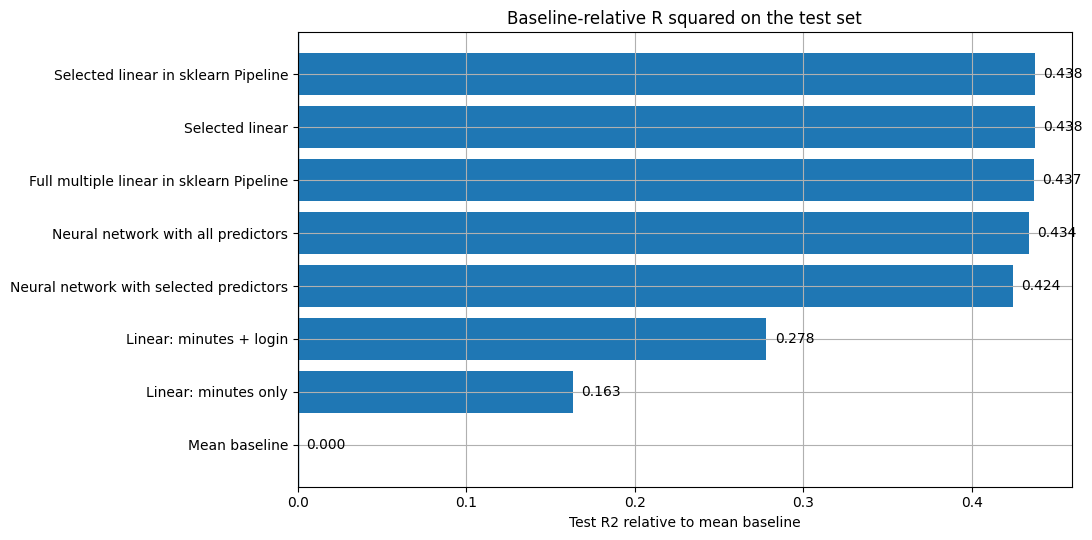

In [15]:
plot_df = test_metrics.sort_values("RMSE", ascending=True)

fig, ax = plt.subplots(figsize=(11, 5.5))
y_positions = np.arange(len(plot_df))
ax.barh(y_positions, plot_df["RMSE"])
ax.set_yticks(y_positions)
ax.set_yticklabels(plot_df["model"])
ax.invert_yaxis()
ax.set_xlabel("Test RMSE")
ax.set_title("Final comparison uses the test set")
for y, value in zip(y_positions, plot_df["RMSE"]):
    ax.text(value + 0.03, y, f"{value:.3f}", va="center")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "lab5_test_model_comparison_rmse.png", dpi=160, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(11, 5.5))
y_positions = np.arange(len(plot_df))
ax.barh(y_positions, plot_df["R2_vs_baseline"])
ax.set_yticks(y_positions)
ax.set_yticklabels(plot_df["model"])
ax.invert_yaxis()
ax.set_xlabel("Test R2 relative to mean baseline")
ax.set_title("Baseline-relative R squared on the test set")
ax.axvline(0, linewidth=1)
for y, value in zip(y_positions, plot_df["R2_vs_baseline"]):
    ax.text(value + 0.005, y, f"{value:.3f}", va="center")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "lab5_test_r2_vs_baseline.png", dpi=160, bbox_inches="tight")
plt.show()

## 14. Train versus test gap

A large gap between train RMSE and test RMSE can indicate poor generalization. It is common for a flexible neural network to look strong on training data but weaker on test data.

In [16]:
rmse_wide = metrics_df.pivot_table(index=["model", "data_method"], columns="split", values="RMSE").reset_index()
rmse_wide["test_minus_train_RMSE"] = rmse_wide["test"] - rmse_wide["train"]
rmse_wide = rmse_wide.sort_values("test").reset_index(drop=True)
rmse_wide

split,model,data_method,test,train,validation,test_minus_train_RMSE
0,Selected linear in sklearn Pipeline,sklearn Pipeline,6.107775,5.978091,6.028068,0.129684
1,Selected linear,generator table,6.107775,5.978091,6.028068,0.129684
2,Full multiple linear in sklearn Pipeline,sklearn Pipeline,6.111016,5.976440,6.027708,0.134575
3,Neural network with all predictors,sklearn Pipeline,6.128472,5.993120,6.080136,0.135352
4,Neural network with selected predictors,sklearn Pipeline,6.178404,6.031481,6.073680,0.146923
5,Linear: minutes + login,generator table,6.919053,6.645940,6.619260,0.273114
6,Linear: minutes only,generator table,7.448923,7.128756,7.079654,0.320167
7,Mean baseline,constant baseline,8.143933,7.770039,7.793683,0.373894


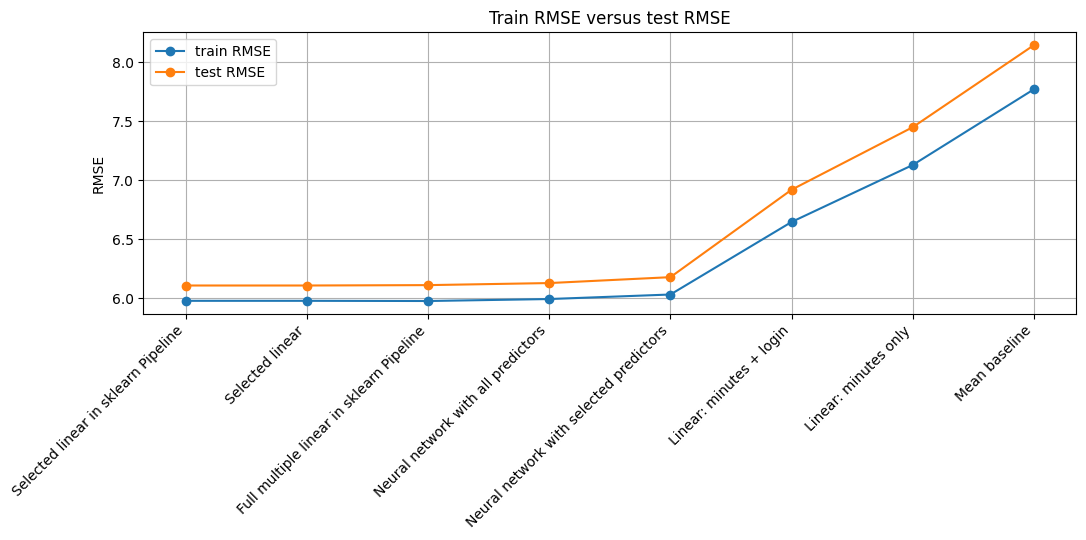

In [17]:
fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(rmse_wide))
ax.plot(x, rmse_wide["train"], marker="o", label="train RMSE")
ax.plot(x, rmse_wide["test"], marker="o", label="test RMSE")
ax.set_xticks(x)
ax.set_xticklabels(rmse_wide["model"], rotation=45, ha="right")
ax.set_ylabel("RMSE")
ax.set_title("Train RMSE versus test RMSE")
ax.legend()
plt.tight_layout()
plt.savefig(ASSETS_DIR / "lab5_train_vs_test_rmse.png", dpi=160, bbox_inches="tight")
plt.show()

## 15. Actual versus predicted values on the test set

Compare the strongest linear model and the neural network. Points closer to the diagonal are better.

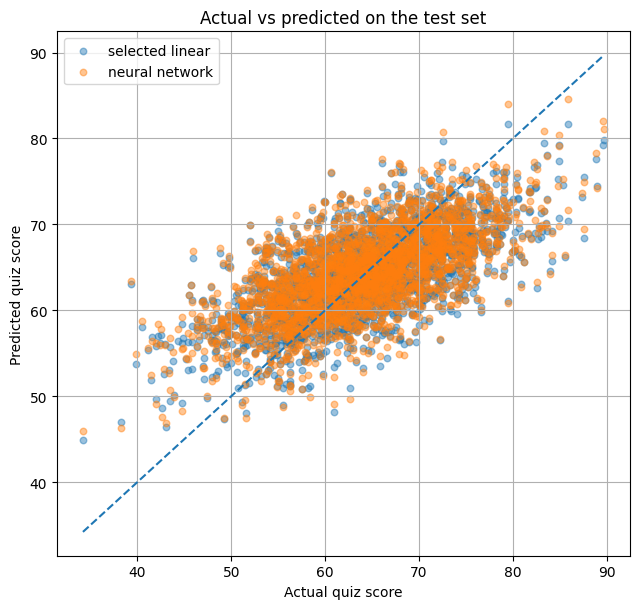

In [18]:
best_linear_name = "Selected linear in sklearn Pipeline"
best_nn_name = "Neural network with all predictors"

linear_model = fitted_models[best_linear_name]
nn_model = fitted_models[best_nn_name]

linear_pred = linear_model.predict(test_df[selected_features])
nn_pred = nn_model.predict(test_df[features])

y_min = min(test_df[target].min(), linear_pred.min(), nn_pred.min())
y_max = max(test_df[target].max(), linear_pred.max(), nn_pred.max())

fig, ax = plt.subplots(figsize=(6.5, 6.2))
ax.scatter(test_df[target], linear_pred, alpha=0.45, s=22, label="selected linear")
ax.scatter(test_df[target], nn_pred, alpha=0.45, s=22, label="neural network")
ax.plot([y_min, y_max], [y_min, y_max], linestyle="--")
ax.set_xlabel("Actual quiz score")
ax.set_ylabel("Predicted quiz score")
ax.set_title("Actual vs predicted on the test set")
ax.legend()
plt.tight_layout()
plt.savefig(ASSETS_DIR / "lab5_test_actual_vs_predicted_models.png", dpi=160, bbox_inches="tight")
plt.show()

## 16. Optional QR decomposition check for selected linear regression

The package model is the main method. QR decomposition is included as a linear-algebra check for the selected linear regression solution.

In [19]:
X_train = train_df[selected_features].to_numpy(float)
y_values = train_df[target].to_numpy(float)

X_design = np.column_stack([np.ones(len(X_train)), X_train])
Q, R = np.linalg.qr(X_design)
beta_qr = np.linalg.solve(R, Q.T @ y_values)

plain_selected_linear = LinearRegression()
plain_selected_linear.fit(train_df[selected_features], train_df[target])
beta_sklearn = np.r_[plain_selected_linear.intercept_, plain_selected_linear.coef_]

coef_compare = pd.DataFrame({
    "term": ["intercept"] + selected_features,
    "QR": beta_qr,
    "sklearn": beta_sklearn,
    "absolute_difference": np.abs(beta_qr - beta_sklearn),
})
coef_compare

,term,QR,sklearn,absolute_difference
0,intercept,48.093738,48.093738,4.263256e-14
1,minutes_studied,0.087163,0.087163,1.110223e-16
2,login_count,0.890871,0.890871,1.110223e-16
3,video_minutes,0.122750,0.122750,5.551115e-17
4,late_submission,-5.256059,-5.256059,2.753353e-14


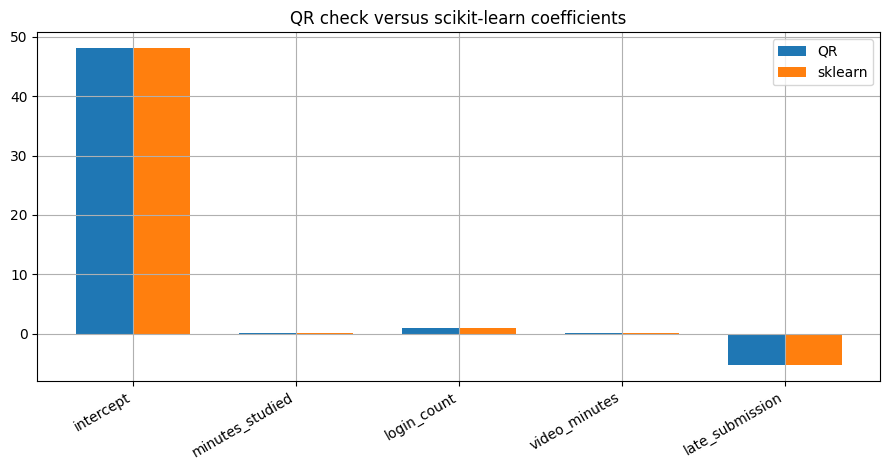

In [20]:
fig, ax = plt.subplots(figsize=(9, 4.8))
x = np.arange(len(coef_compare))
width = 0.35
ax.bar(x - width/2, coef_compare["QR"], width, label="QR")
ax.bar(x + width/2, coef_compare["sklearn"], width, label="sklearn")
ax.set_xticks(x)
ax.set_xticklabels(coef_compare["term"], rotation=30, ha="right")
ax.set_title("QR check versus scikit-learn coefficients")
ax.legend()
plt.tight_layout()
plt.savefig(ASSETS_DIR / "lab5_qr_vs_sklearn_selected_coefficients.png", dpi=160, bbox_inches="tight")
plt.show()

## 17. Practice tasks

1. Change the variable-selection threshold from `0.02` to `0.00`. Which variables are selected?
2. Replace the neural network hidden layers `(32, 16)` with `(16, 8)`. Does the test RMSE improve?
3. Compare `Generator table + selected linear` with `Selected linear in sklearn Pipeline`. Why are their metrics nearly the same?
4. Find the model with the best test RMSE. Does it also have the best training RMSE?
5. Explain why test performance is more important than training performance for model comparison.